In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [2]:
import scipy
import tensiometer
# from tensiometer.utilities import stats_utilities as utilities
import tensiometer.utilities as utilities
from tensiometer import mcmc_tension
from tensiometer import gaussian_tension

In [3]:
true_params = np.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

In [4]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

In [5]:
labels_subset = [r"$\Omega_{m}$", r"$\sigma_8$", r"$w_0$"]

# Subset indices from the original labels
subset_indices = [0, 1, 2]  # indices of the first 3 parameters in your labels list
true_params_subset = true_params[0, subset_indices]

def subset_mcsamples(mcsamples, indices):
    # Extract subset of samples corresponding to the desired parameters
    # samples array shape: (num_samples, num_params)
    subset_samples = mcsamples.samples[:, indices]
    subset_labels = [labels[i] for i in indices]
    # Recreate MCSamples object with subsets
    return MCSamples(samples=subset_samples, names=subset_labels, label=mcsamples.label)

### Tomo

In [11]:
pc_sc2 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_pc_nobaryons_vs_baryonified_bins1234_scales234_noisy_s0.26_new_normalization_npe.npy')
pc_sc2_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_pc_nobaryons_vs_nobaryons_bins1234_scales2345_noisy_s0.26_new_normalization_npe.npy')

pc_sc1_unb = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_pc_nobaryons_vs_nobaryons_bins1234_scales123_noisy_s0.26_new_normalization_npe.npy')
pc_sc1 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_pc_nobaryons_vs_baryonified_bins1234_scales1234_noisy_s0.26_new_normalization_npe.npy')

In [12]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

pc_sc1 = MCSamples(
    samples=pc_sc1,
    names=labels,
    label="pc scales 1,2,3,4"
)
pc_sc2 = MCSamples(
    samples=pc_sc2,
    names=labels,
    label="pc scales 2,3,4"
)

pc_sc1_unb = MCSamples(
    samples=pc_sc1_unb,
    names=labels,
    label="pc unb scales 1,2,3"
)
pc_sc2_unb = MCSamples(
    samples=pc_sc2_unb,
    names=labels,
    label="pc unb scales 2,3,4,5"
)


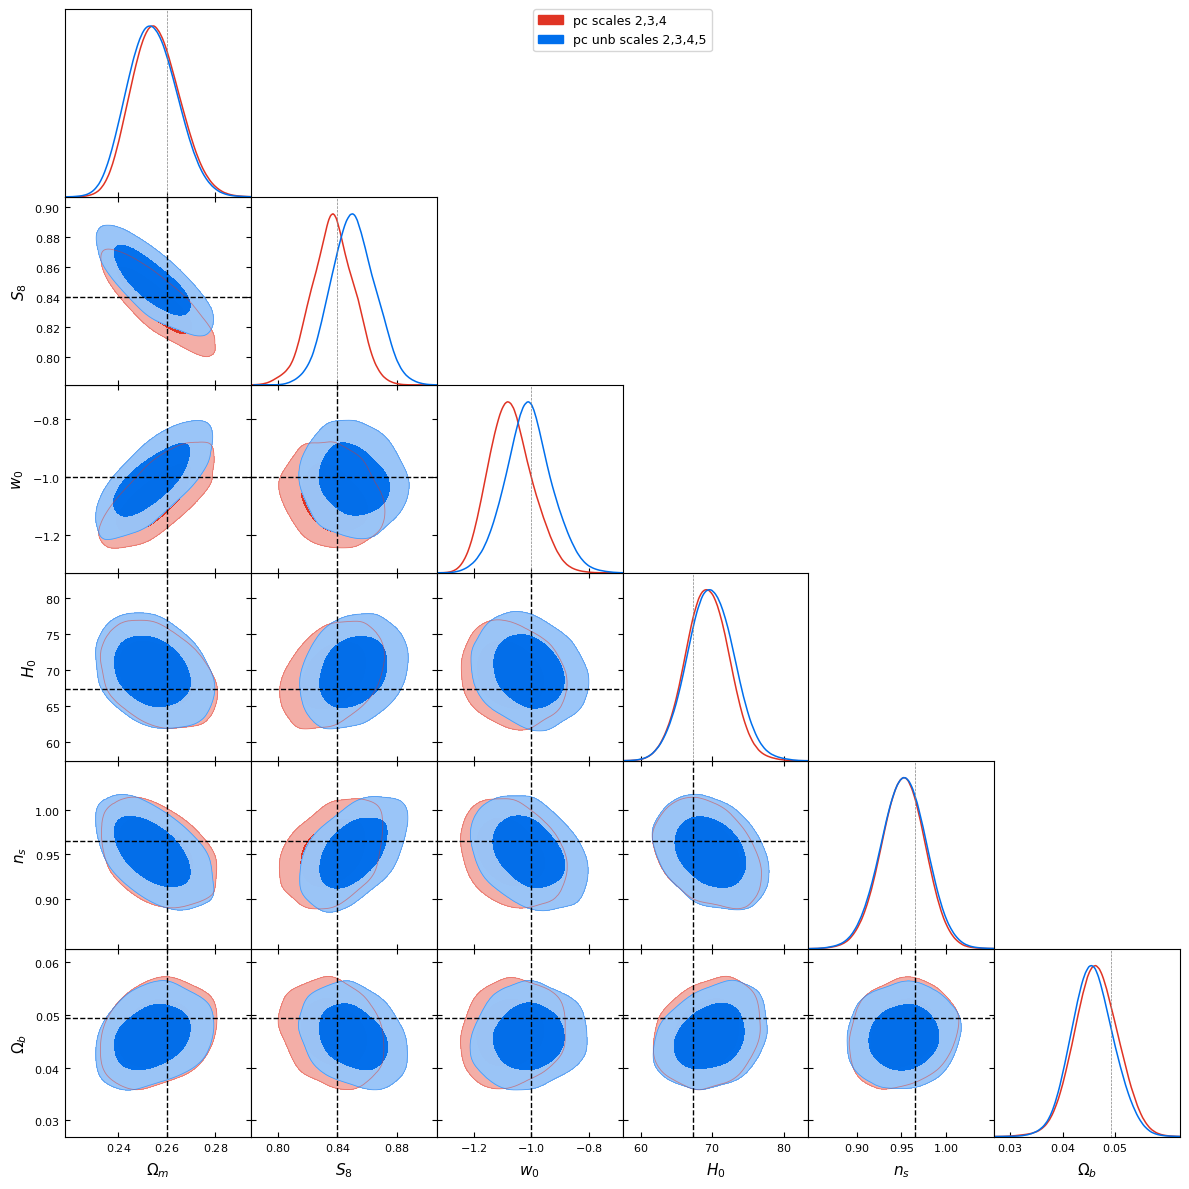

In [14]:
g = plots.get_subplot_plotter()
g.settings.alpha_filled_add = 0.99

g.triangle_plot([pc_sc2, pc_sc2_unb],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()

In [15]:
Q_DM, Q_DM_dofs = gaussian_tension.Q_DM( pc_sc2, pc_sc2_unb )
Q_DM_P = scipy.stats.chi2.cdf(Q_DM, Q_DM_dofs)
# print everything:
print(f'Q_DM = {Q_DM:.2f}, dofs = {Q_DM_dofs:2}, P = {Q_DM_P:.5f}')
# convert to effective number of sigmas:
Q_DM_nsigma = utilities.from_confidence_to_sigma(Q_DM_P)
# print everything:
print(f'nsigma = {Q_DM_nsigma:.3f}')

Q_DM = 0.97, dofs =  6, P = 0.01336
nsigma = 0.017


## Compare all scale-cutted stats

In [24]:
l1_sc2 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_nobaryons_vs_baryonified_bins1234_scales234_noisy_s0.26_new_normalization_npe.npy')
ps_tomo_500 = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-800_r20_noisy_s0.26_npe.npy')
ps_tomo_540_masked = np.load('/home/tersenov/software/bar_impact/outputs/samples/posterior_samples_ps_nobaryons_vs_baryonified_bins1234_l30-540_r20_masked_14300sqdeg_noisy_s0.26_npe.npy')

l1_sc2 = MCSamples(
    samples=l1_sc2,
    names=labels,
    label="l1 scales 2,3,4"
)
ps_tomo_500 = MCSamples(
    samples=ps_tomo_500,
    names=labels,
    label="ps tomo 500"
)
ps_tomo_540_masked = MCSamples(
    samples=ps_tomo_540_masked,
    names=labels,
    label="ps tomo 540 masked"
)

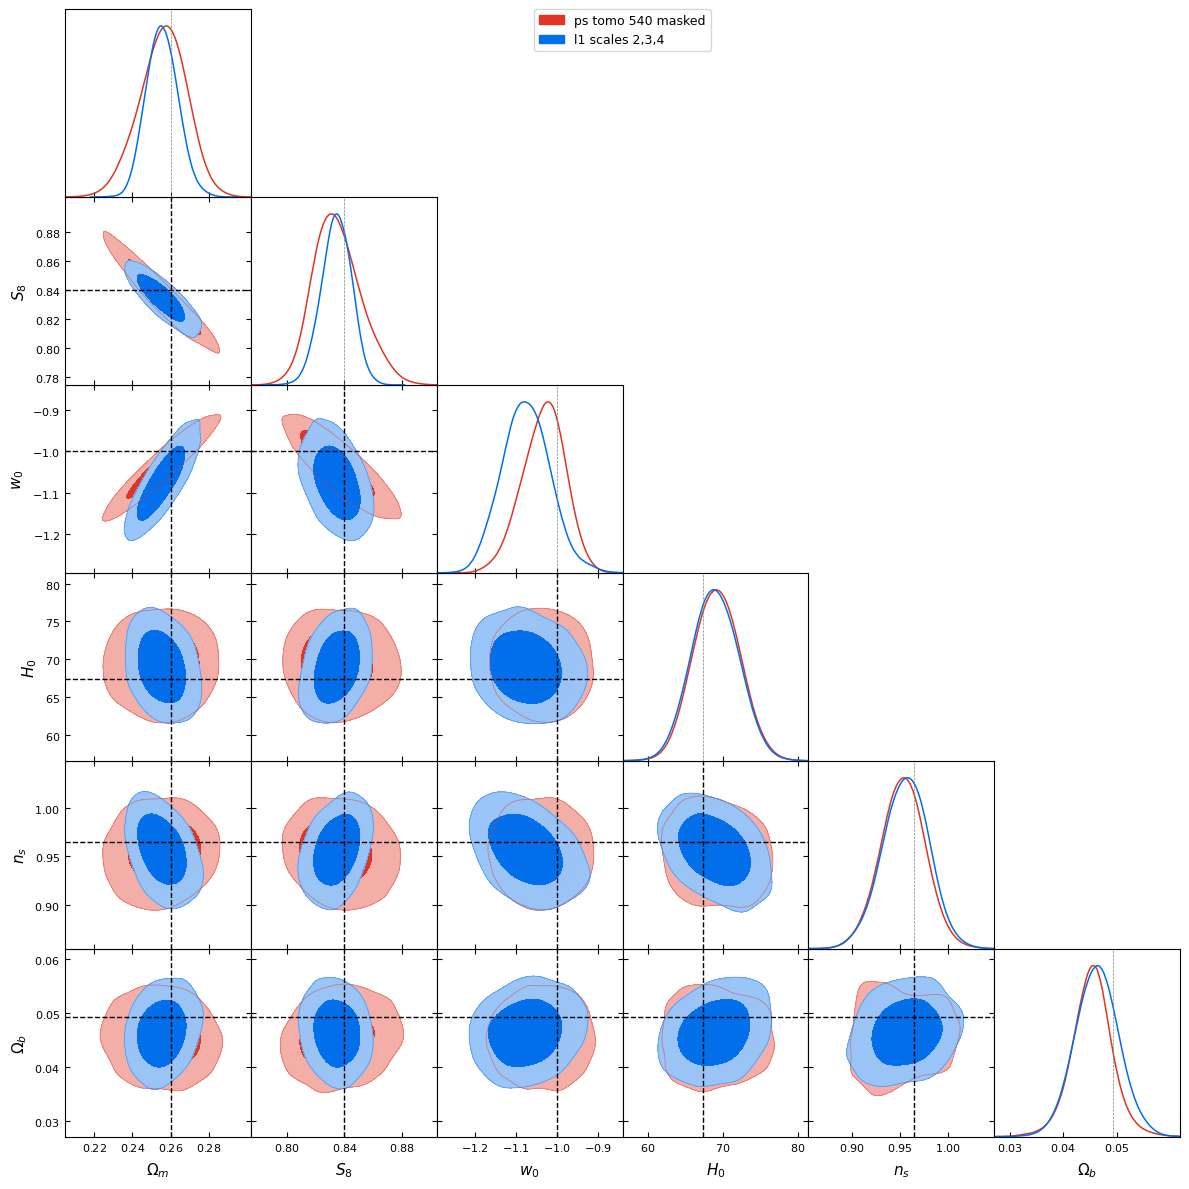

In [27]:
g = plots.get_subplot_plotter()
g.settings.alpha_filled_add = 0.99

g.triangle_plot([ps_tomo_540_masked, l1_sc2],
                filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )

plt.show()